[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danieldidriksen/Bachelor_Project/blob/main/NYC_Orientation_Analysis.ipynb)

# Importin the Library

In [4]:
try:
    from Image_analysis_class import ImageAnalyzer as IA

except ModuleNotFoundError:
    !git clone https://github.com/danieldidriksen/Bachelor_Project.git
    from Bachelor_Project.Image_analysis_class import ImageAnalyzer as IA

## Importing your image, converting it to grayscale and printing it

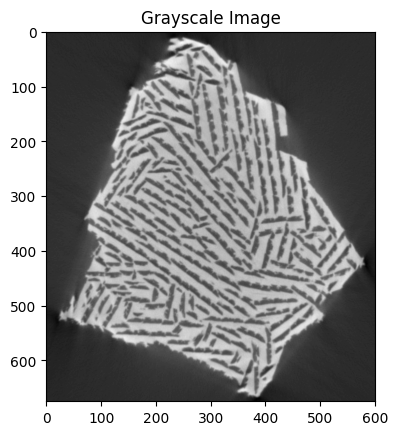

In [ ]:
# For importing image when working in vscode
try:
    imagefile = r"Images\Ceramic.jpg"
    img = IA.load_grayscale(imagefile)

# For importing image when working in colab
except:
    imagefile = r"Bachelor_Project\Images\eramic.jpg"
    img = IA.load_grayscale(imagefile)

# Crop if needed
img = img[180:-169,180:-219] 

IA.plot_image(img)

# Part 2: Creating the Structure Tensor

## Computing gradients while smoothing the pictures

In [7]:
S = IA.compute_structure_tensor(img, 1, 7)

# Part 3: Finding the dominant orientation

## Eigen Decomposition

In [8]:
evals, evecs = IA.eigendecomposition(S)

lam_small, lam_large, v_small, v_large  = IA.split_eigenpairs(evals, evecs)

theta = IA.orientation_from_eigenvectors(v_small)

vx, vy = IA.orientation_to_unit_vectors(theta)

## Plotting the Dominant Orientations

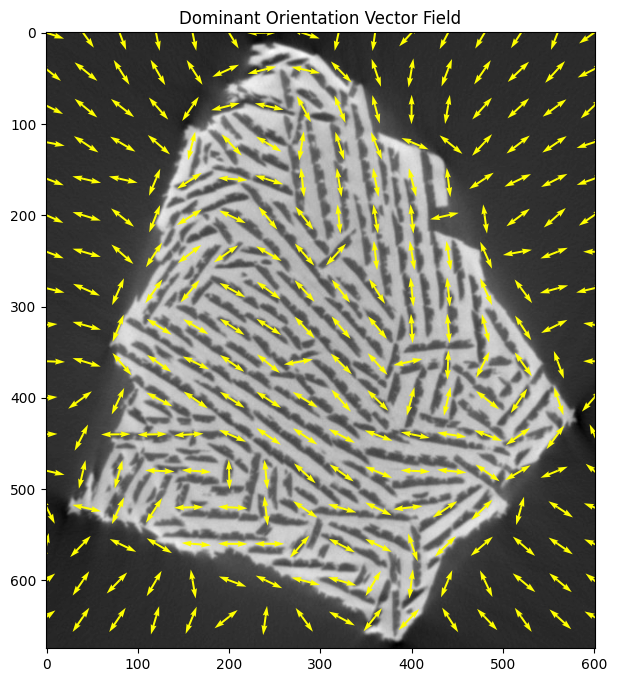

In [9]:
IA.plot_orientation_vectors(img, S, 40, 50)

# Part 4: Histogram and Colour Overlay

## Overlaying on picture

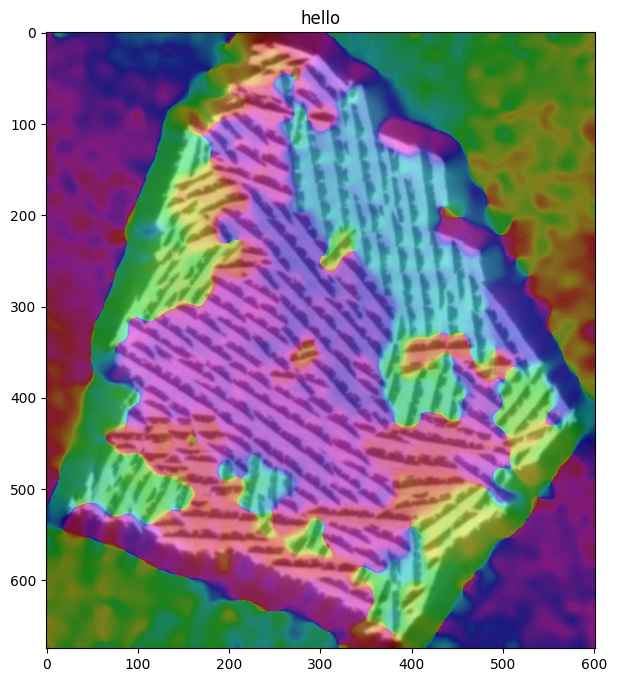

In [10]:
IA.plot_orientation_overlay(img, theta, opaqueness=0.40, title= "hello") 

## Making histogram

In [11]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta)

## Plotting histogram

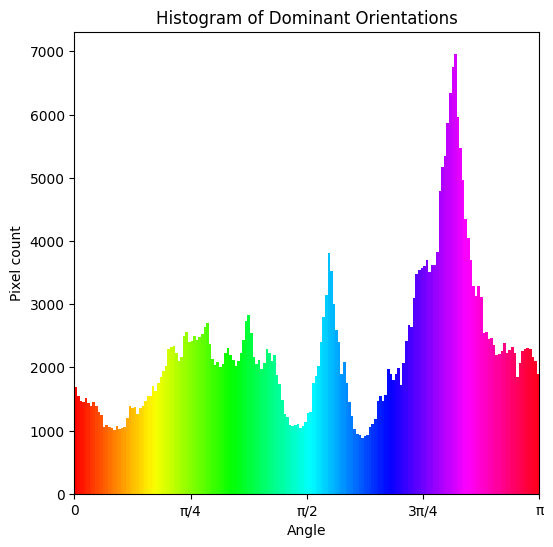

In [12]:
IA.plot_orientation_histogram(counts, bin_centers, bin_width, weighted = False)

## Making and plotting polar histogram

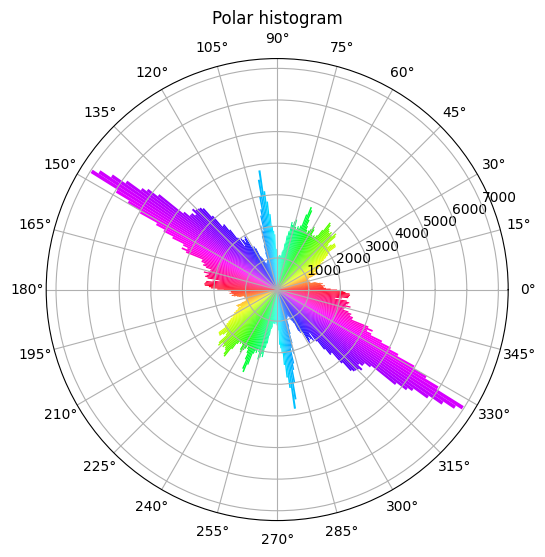

In [13]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = False)

# Part 5: Isotropy

## Applying Isotropy mask

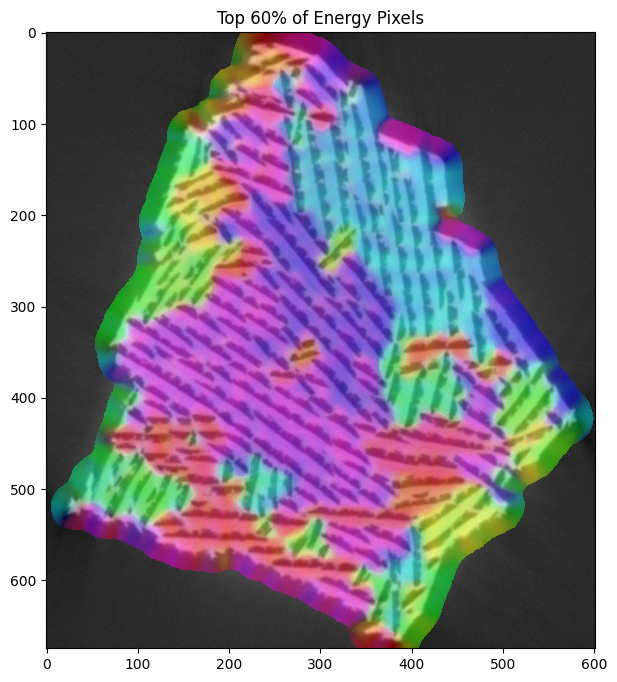

In [14]:
percent = 40
anisotropy_masked = IA.compute_anisotropy_masked(S, percent)

IA.plot_orientation_overlay(img, theta, anisotropy_masked, percent)


## Calculating and plotting weighted Histogram

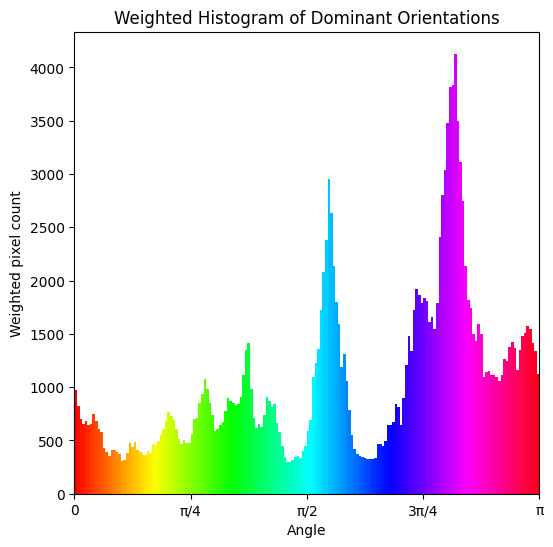

In [15]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta, anisotropy_masked)
IA.plot_orientation_histogram(counts, bin_centers, bin_width, weighted = True)

## Plotting weighted Polar Histogram

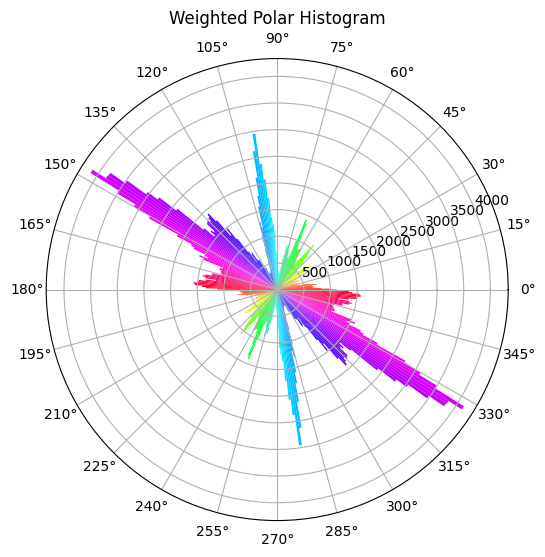

In [16]:
IA.plot_polar_histogram(counts, bin_centers, bin_width, weighted = True)

## Applying Isotropy mask with orientation groupings

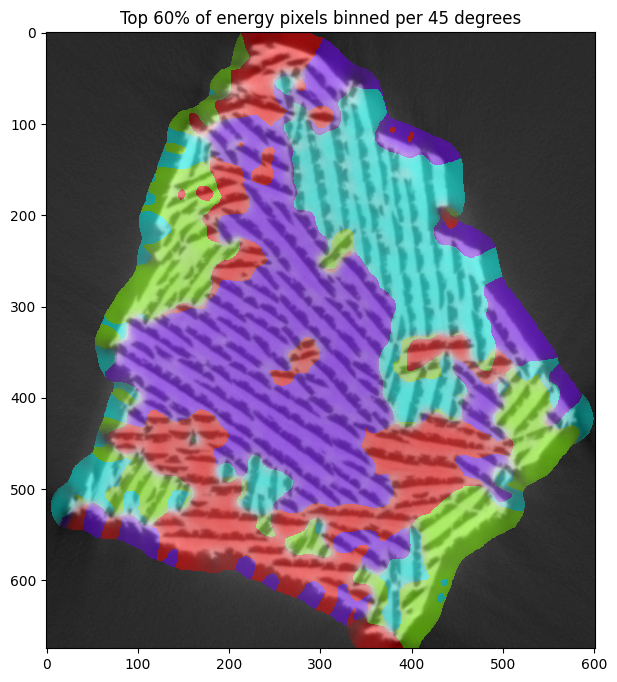

In [17]:
# compute theta binned:
theta_binned = IA.bin_orientations_uniform(theta, 45)

IA.plot_orientation_overlay(img, theta_binned, anisotropy_masked, percent, title="Top 60% of energy pixels binned per 45 degrees")


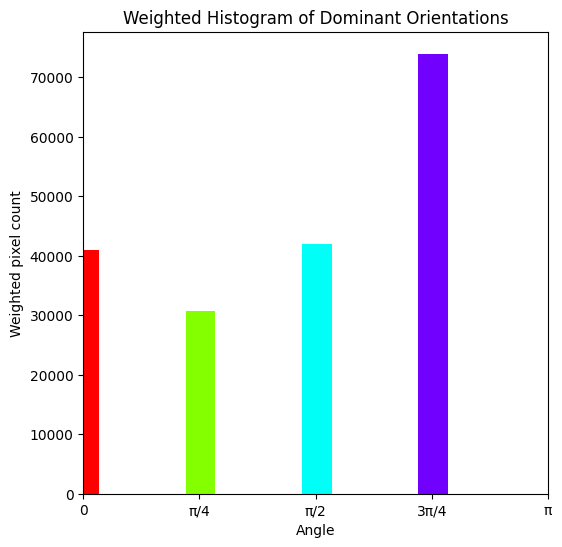

In [18]:
counts, bin_centers, bin_width = IA.compute_orientation_histogram(theta_binned, anisotropy_masked)

IA.plot_orientation_histogram(counts, bin_centers, 0.2, weighted = True)

In [19]:
#percentile of pixels which are binned to 135 degrees:
73947.52989116/(40989.85696096 + 30658.14674817 + 42010.12788124 + 73947.52989116)*100

39.41647032781056

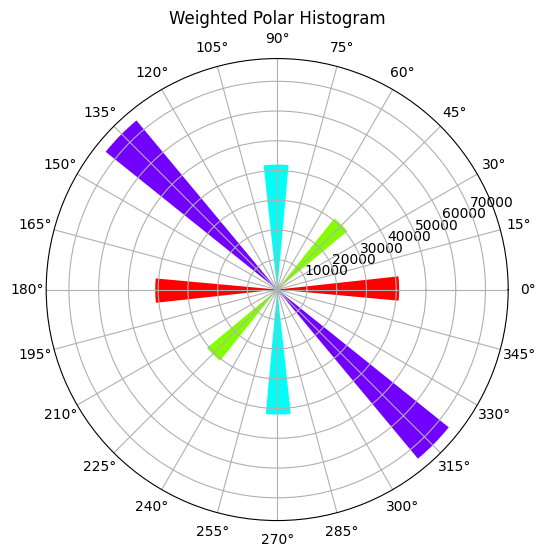

In [20]:
IA.plot_polar_histogram(counts, bin_centers, 0.2, weighted= True)